<font size="1"> *This notebook is best viewed in jupyter lab/notebook. You may also choose to use Google Colab but some parts of the images/colouring will not be rendered properly.</font> 

<div class="alert alert-block alert-warning">
    
# Assignment

Welcome to task 3 of the assignment! This notebook contains all the code and comments that you need to submit. The places where you need to edit are highlighted in red. Feel free to add in your own markdown for additional comments.

__Submission details: make sure you all your outputs have been generated. Submit this Jupyter Notebook.__

<b>Enter you student details below</b>

- <b>Student Name:</b> Wenxing Du
- <b>Student ID:</b> 30171857  

<div class="alert alert-block alert-danger">

# Table of Contents

* [Libraries](#Libraries)
    
* [Task 3.1: Download the GTSRB Train and Test set](#t3_1)
    
* [Task 3.2: Visualise a few training samples](#t3_2)
    
* [Task 3.3: Define a CNN Model](#t3_3)
    
* [Task 3.4: Train and evaluate CNN model](#t3_4)
    
* [Task 3.5: Visualise the results](#t3_5)
    
* [Task 3.6: Discussion Questions](#t3_6)

<div class="alert alert-block alert-warning">

# Libraries

Libraries are important as it saves us time from writing our own functions all the time such as graphing, or creating matrices. Brief library descriptions have been added for every library that we import. You may also check the official documentations for more details.

The required libraries are specified in this notebook for you.

In [175]:
# Mount Google Drive
import os
try:
    from google.colab import drive
    colabFlag = True
    
    PATH_DATASETS = '/content/gdrive/MyDrive/...' # Add in your own path here to the folder containing the data
    # mount Google Drive
    drive.mount('/content/gdrive')
    print(f"Using Google Colab with file path {PATH_DATASETS}")
except:
    colabFlag = False

    PATH_DATASETS = os.environ.get("PATH_DATASETS", "./data")

    print(f"Not using Google Colab. File path will be: {PATH_DATASETS}")

Not using Google Colab. File path will be: ./data


In [176]:
# If you run on google colab uncomment bellow comment
# !pip install torchmetrics pytorch-lightning torchvision -qq
# !pip install imutils

import copy
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from math import *

import torch
import torchvision
from torchvision.datasets import GTSRB
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchmetrics import Accuracy

import pytorch_lightning as pl # Pytorch lightning is a wrapper for pytorch that makes it easier to train models
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import Callback, ModelCheckpoint, EarlyStopping
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# from carbontracker.tracker import CarbonTracker
from torch.optim.lr_scheduler import StepLR

# Setting seeds for reproducibility
pl.seed_everything(4179)
random.seed(4179)
np.random.seed(4179)

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'


BATCH_SIZE = 256 if torch.cuda.is_available() else 64
# Define GPU number
GPU_indx = 0
device = torch.device(GPU_indx if torch.cuda.is_available() else 'cpu')
num_workers = 0 # Set to your device

Seed set to 4179


<div class="alert alert-block alert-info">
    
# Image Classification on the GTSRB dataset
    
# What you should do in this task!

In this task you will be training a Convolutional Neural Network (CNN) with the GTSRB dataset using Pytorch and PyTorch Lightning funtionalities we have previously seen!

You have to use Pytorch inbuilt datasets, the Pytorch Lightning module class to construct MLP and CNN, and stochastic gradient descent (SGD) in order to perform training on the GTSRB dataset.
    
## In this task, you will work on the following points:
 1. Download the GTSRB Train and Test set
 2. Visualise a few training samples
 3. Define a CNN Model
 4. Train and evaluate CNN model
 5. Visualise the results and apply additional analysis here
 6. Discussion Questions

<img src="figures/GTSRB.jpg" width="700" align="center">

<div class="alert alert-block alert-info">
    
## Task 3.1: Download the GTSRB Train and Test set <a class="anchor" id="t3_1"></a>

The  German Traffic Sign Recognition Benchmark (GTSRB) is a a multi-class, single-image classification benchmark dataset. There are 43 classes in total, and more than over 50,000 images. There are 39,209 training examples, 12,630 test examples.

More about GTSRB dataset: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Pytorch has constructed a number of "dataset" classes that will automatically download various datasets making it very easy for us to train our models.

In [177]:
# Define transform to convert image into a Tensor
transform = transforms.Compose([transforms.Resize((28, 28)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Init Train DataLoader from GTSRB Dataset
train_ds = GTSRB(PATH_DATASETS, split="train", download=True, transform=transform)

# Perform Random Split for training and validation
train_ds, val_ds = random_split(train_ds, [int(len(train_ds)-math.floor(len(train_ds)*0.2)), math.ceil(int(len(train_ds)*0.2))])

val_loader = DataLoader(val_ds, shuffle=False, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True) 
train_loader = DataLoader(train_ds, shuffle=True, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True) 

# Init Test DataLoader from GTSRB Dataset
test_ds = GTSRB(PATH_DATASETS, split="test", download=True, transform=transform)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True) 

# Read the categories from the text file given: gtsrb_classes.txt
# This contains all 43 classes
with open(PATH_DATASETS + "/gtsrb_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# The code has been done for you in 3.1 

<div class="alert alert-block alert-info">
    
## Task 3.2: Visualise a few training samples <a class="anchor" id="t3_2"></a>
Let's first take a closer look at the shapes of the dataset, and then visualise the mini-batches that the dataloader gives us. Ensure you have reversed the normalization before plotting.

In [178]:
# Check the shapes of the batch data in train_loader
print(f"train_loader batch shape: {next(iter(train_loader))[0].shape}")
print(f"val_loader batch shape: {next(iter(val_loader))[0].shape}")
print(f"test_loader batch shape: {next(iter(test_loader))[0].shape}")

train_loader batch shape: torch.Size([256, 3, 28, 28])
val_loader batch shape: torch.Size([256, 3, 28, 28])
test_loader batch shape: torch.Size([256, 3, 28, 28])


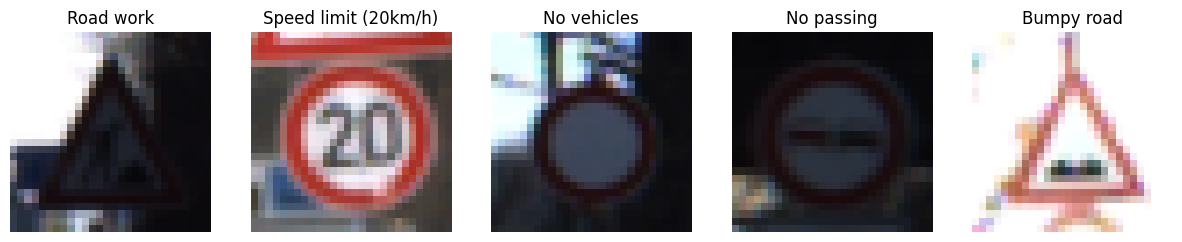

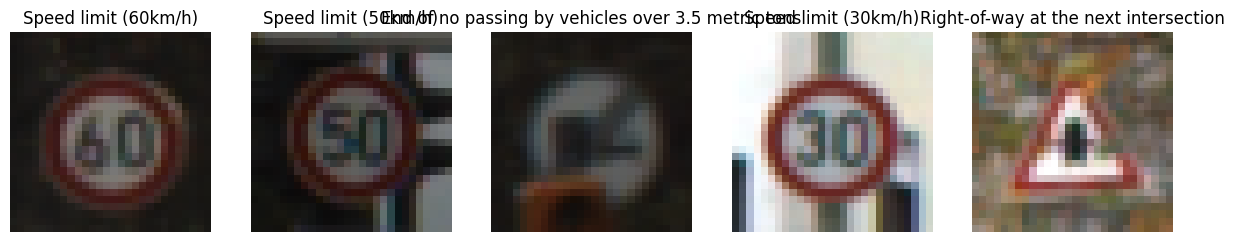

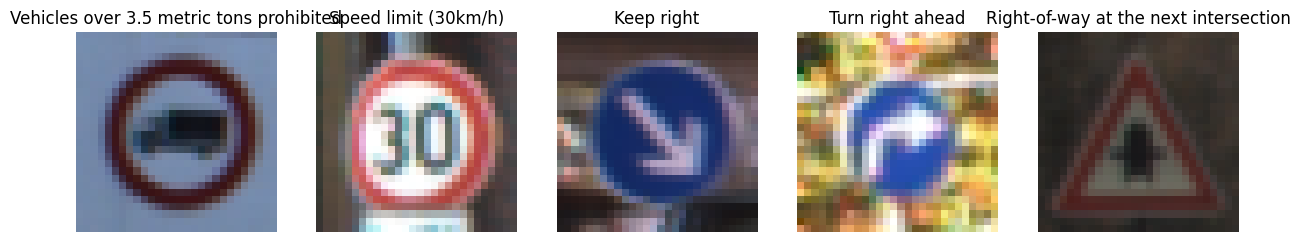

In [179]:
# Check a few images of some images
# Ensure you have inverse the normalization before plotting.

# inverse the normalization
def inverse_normalize(tensor, mean, std):
    
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  
    return tensor


def visualize_dataloader(dataloader, class_names):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    images, labels = next(iter(dataloader))  

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(5):
       
        image = images[i].clone()  # clone
        image = inverse_normalize(image, mean, std)  # inverse_normalize
        image = image.permute(1, 2, 0).numpy()  # to (H, W, C)
        image = image.clip(0, 1)  # Limit pixel values ​​to the range [0, 1]
        
        label = labels[i]  
        axes[i].imshow(image)
        axes[i].set_title(class_names[label.item()])
        axes[i].axis('off')

    plt.show()


visualize_dataloader(train_loader, categories)
visualize_dataloader(val_loader, categories)
visualize_dataloader(test_loader, categories)



<div class="alert alert-block alert-info">
    
## Task 3.3: Define a CNN Model <a class="anchor" id="t3_3"></a>
    
Define the models using the LightningModule class as usual.

In [180]:
# We will use modular convolutional blocks. 
# Define a convolutional layer along with an activation function
# Remember, you can use other techniques you have learnt from the lectures and workshops such as dropout, batchnorm, pooling etc.

class ConvBlock(nn.Module):

    def __init__(self, channels_in, channels_out):
        super(ConvBlock, self).__init__()     # Call constructor
        self.conv = nn.Conv2d(channels_in, channels_out, kernel_size=3, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(channels_out)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        
        return x

#Let's create a simple CNN for image classification
class Simple_CNN(pl.LightningModule):
    
    def __init__(self, num_classes=43, learning_rate=1e-2):
        super().__init__()
        
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.criterion = nn.CrossEntropyLoss()
        
        # Initialise at least 2 convolutional blocks with
        self.conv_blk1 = ConvBlock(3, 32)
        self.conv_blk2 = ConvBlock(32,64)
        
        # You can use other layers too, feel free to define them here
        self.conv_blk3 = ConvBlock(64, 128)
        
        # You will need to define your fully connected layer:
        self.fc = nn.Linear(1152, self.num_classes) 

        # Define your accuracies        
        self.train_acc = Accuracy(task='multiclass', num_classes=10)
        self.val_acc = Accuracy(task='multiclass', num_classes=10)
        self.test_acc = Accuracy(task='multiclass', num_classes=10)

    
        
        
    def forward(self, x):

        #print(f"Input shape: {x.shape}")

        x = self.conv_blk1(x)

        #print(f"After conv_blk1: {x.shape}")

        x = self.conv_blk2(x)

        #print(f"After conv_blk2: {x.shape}") 

        x = self.conv_blk3(x)

        #print(f"After conv_blk3: {x.shape}")

        x = x.view(x.size(0), -1)  

        #print(f"After flatten: {x.shape}")

        x = self.fc(x)

        #print(f"After fc: {x.shape}") 
        
        return x
        
       
    
    def training_step(self, batch, batch_idx):

        images, labels = batch
        preds = self(images)
        loss = self.criterion(preds, labels)
        acc = (preds.argmax(dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, prog_bar=True)
        return loss


    def validation_step(self, batch, batch_idx):
    
        images, labels = batch
        preds = self(images)
        loss = self.criterion(preds, labels)
        acc = (preds.argmax(dim=1) == labels).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
        
        

    def test_step(self, batch, batch_idx):

        images, labels = batch
        preds = self(images)
        loss = self.criterion(preds, labels)
        acc = (preds.argmax(dim=1) == labels).float().mean()
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)

        return preds
        

    def configure_optimizers(self):
        optimizer =  torch.optim.Adam(self.parameters(), lr=self.learning_rate)

        return optimizer

    ##########
    # DATA RELATED HOOKS
    ##########

    def train_dataloader(self):
        return train_loader
    def val_dataloader(self):
        return val_loader
    def test_dataloader(self):
        return test_loader

<div class="alert alert-block alert-info">
    
## Task 3.4: Train and evaluate CNN model <a class="anchor" id="t3_4"></a>
    
Define VisualizeSamplePredictionsCallback using Callback class. You have to visualise 4 sample predictions from the first batch at the end of testing. This will redefine the on_test_batch_end function.

Here is a sample image:
    
<img src="figures/sample_predictions_reel.png" width="700" align="center">

Make sure to display actual category of Ground truth and Prediction by reading the given text file.
   
    
In PyTorch Lightning, callback functions are used to customize and extend the behavior of your training loops without cluttering your main code. Callbacks are objects that you can attach to your LightningModule and customize various aspects of the training process, such as logging, early stopping, model checkpointing, and more. We are updating the callback of the  the _on_test_batch_end method derived from the pytorch lightning module.

In [181]:
class VisualizeSamplePredictionsCallback(Callback):
    
    def on_test_batch_end(
        self, trainer, pl_module, outputs, batch, batch_idx):
        """Called when the test batch ends."""
 
        # `outputs` comes from `LightningModule.test_step`, so make sure to return prediction in test_step 
        # which corresponds to our model predictions during testing time in this case
        # Let's log 4 sample image predictions from first batch
        # Make sure to do inverse normalizing before you plot original images
        # Also, make sure to display corresponding actual class name for ground truth and prediction
        
        # You can ignore the input "dataloader_id"
        if batch_idx == 0:

            x, y = batch
            preds = torch.argmax(outputs, dim=1)

            # # If you are using cuda, then you need to use the three lines below
            # x = x.cpu() 
            # y = y.cpu()
            # outputs = outputs.cpu()



            fig, ax = plt.subplots(1, 4, figsize=(20, 20))
            
            # Apply your inverse normalization before plotting
            for i in range(4):

                image = x[i].permute(1, 2, 0).cpu().numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
                image = image.clip(0, 1)  
                
                
                ax[i].imshow(image)
                ax[i].axis('off')
                
                ax[i].set_title(f'G: {y[i].item()} P: {preds[i].item()}', fontsize=12)
                
               
            
            plt.show()
                

In [182]:


visualize_callback = VisualizeSamplePredictionsCallback()

# Initialize the CNN model
max_epochs = 30 # Feel free to change this
model_cnn = Simple_CNN()

# Initialize checkpoint callback to save the best model using validation loss
checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        dirpath="checkpoints_section_3/",
        save_top_k=1,        
        mode="min",
        every_n_epochs=1
    )

# Stop after 5 epochs of no improvement in validation loss
early_stopping = EarlyStopping('val_loss', patience = 5, mode='min') 

# Call the Trainer and train the model
trainer_task = pl.Trainer(
    accelerator="auto",
    devices=1 if torch.cuda.is_available() else None,  # limiting got iPython runs
    max_epochs=max_epochs,
    callbacks=[TQDMProgressBar(refresh_rate=20), checkpoint_callback,visualize_callback],
    logger=CSVLogger(save_dir="logs_task_3"),
)




GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [183]:
# Train the model
trainer_task.fit(model_cnn)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | criterion | CrossEntropyLoss   | 0      | train
1 | conv_blk1 | ConvBlock          | 960    | train
2 | conv_blk2 | ConvBlock          | 18.6 K | train
3 | conv_blk3 | ConvBlock          | 74.1 K | train
4 | fc        | Linear             | 49.6 K | train
5 | train_acc | MulticlassAccuracy | 0      | train
6 | val_acc   | MulticlassAccuracy | 0      | train
7 | test_acc  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
143 K     Trainable params
0         Non-trainable params
143 K     Total params
0.573     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


c:\Users\dwx\anaconda3\envs\ECE4179_2\lib\site-packages\pytorch_lightning\trainer\connectors\checkpoint_connector.py:145: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at C:\Users\dwx\Desktop\4179\4179_Assignment_2024\checkpoints_section_3\epoch=21-step=1848.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\dwx\Desktop\4179\4179_Assignment_2024\checkpoints_section_3\epoch=21-step=1848.ckpt
c:\Users\dwx\anaconda3\envs\ECE4179_2\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoa

Testing: |          | 0/? [00:00<?, ?it/s]

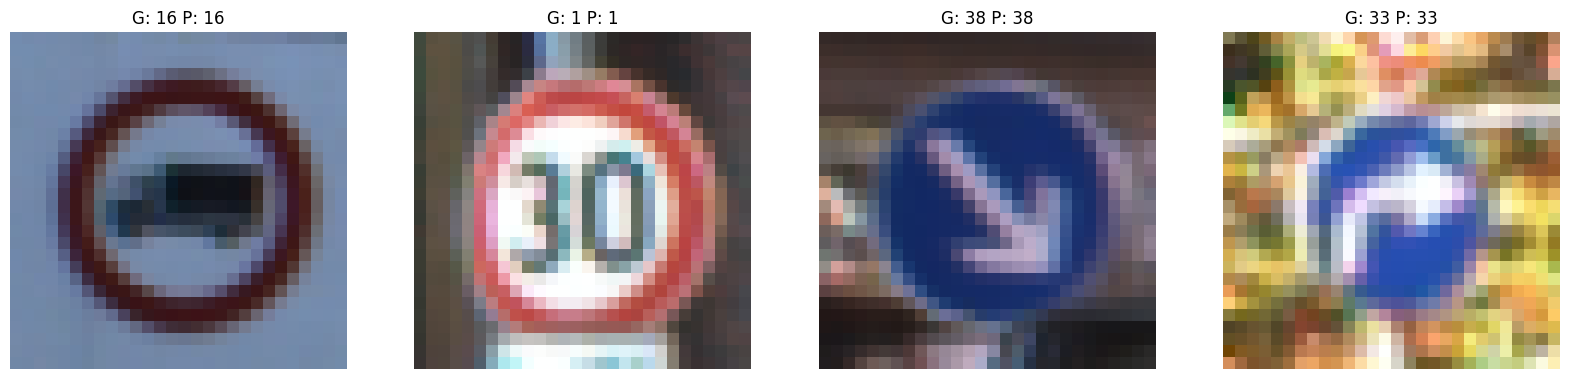

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9135391712188721
        test_loss           0.46794041991233826
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.46794041991233826, 'test_acc': 0.9135391712188721}]

In [184]:
# Test the model and report test accuracy and test loss
trainer_task.test()

<div class="alert alert-block alert-info">
    
## Task 3.5: Visualise the results and apply additional analysis here <a class="anchor" id="t3_5"></a>

Using log files and matplotlib, plot train loss, validation loss, train accuracy, and validation accuracy.

In [185]:
print(metrics_task.columns)
print(metrics_task.head())  


Index(['test_acc', 'test_loss', 'train_acc_epoch', 'train_acc_step',
       'train_loss_epoch', 'train_loss_step', 'val_acc', 'val_loss'],
      dtype='object')
       test_acc  test_loss  train_acc_epoch  train_acc_step  train_loss_epoch  \
epoch                                                                           
0           0.0        0.0         0.372748        0.394531          2.438296   
1           0.0        0.0         0.885088        1.734375          0.368740   
2           0.0        0.0         0.977524        1.957031          0.081349   
3           0.0        0.0         0.985642        0.988281          0.050153   
4           0.0        0.0         0.995542        1.996094          0.019498   

       train_loss_step   val_acc  val_loss  
epoch                                       
0             1.946572  0.700263  0.991728  
1             0.859648  0.958146  0.143126  
2             0.150806  0.932808  0.226350  
3             0.044123  0.959272  0.128494  
4

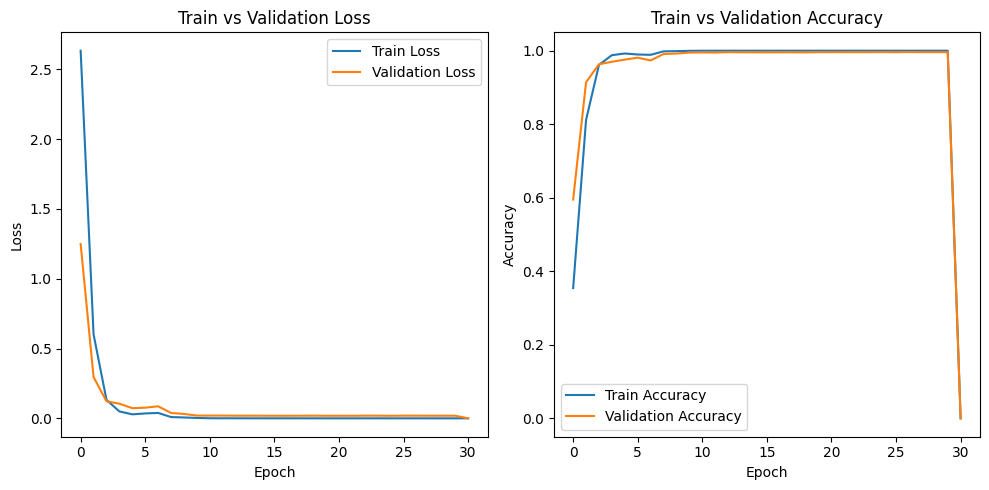

In [186]:
# Show the CNN training and validation curves.
# You can use your own way of logging if you do not want to use tensorboard.
metrics_task = pd.read_csv(trainer_task.logger.log_dir + "/metrics.csv")
metrics_task.set_index("epoch", inplace=True)
metrics_task = metrics_task.groupby(level=0).sum().drop("step", axis=1)

# Draw training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(metrics_task.index, metrics_task['train_loss_epoch'], label='Train Loss')
plt.plot(metrics_task.index, metrics_task['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()

# Draw training and validation accuratecy
plt.subplot(1, 2, 2)
plt.plot(metrics_task.index, metrics_task['train_acc_epoch'], label='Train Accuracy')
plt.plot(metrics_task.index, metrics_task['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Add in your other analysis here. You can choose two (or more) of the following (or any others that are not on this list):

- Feature maps at the outputs of each __CNN block__ for a correctly classified road sign
- Saliency map on a correctly classified road sign
- Top 5 incorrectly classified road signs
- Occlusion sensitivity on a few images
- Confusion matrix on a subset of classes (~15 classes)

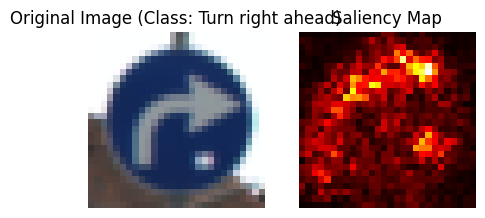

In [235]:
def denormalize(image, mean, std):
    mean = np.array(mean).reshape(1, 1, 3)
    std = np.array(std).reshape(1, 1, 3)
    return image * std + mean

def generate_saliency_map(model, dataloader, class_names):
    model.eval()
    model = model.cuda()
    
    # Randomly select an image that is correctly classified
    for images, labels in dataloader:
        images, labels = images.cuda(), labels.cuda()  
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Get the correctly classified sample index
        correct_indices = (predicted == labels).nonzero(as_tuple=True)[0]
        if len(correct_indices) > 0:
            index = correct_indices[torch.randint(len(correct_indices), (1,)).item()]  
            break
    
    # Select correctly categorized images and tags
    image = images[index].unsqueeze(0)
    label = labels[index]
    
    # Compute saliency map
    image.requires_grad_()  
    output = model(image)
    score = output[0, label]
    score.backward()  # Backpropagation of scores for correct categories

    # Compute saliency
    saliency, _ = torch.max(image.grad.data.abs(), dim=1)
    saliency = saliency.squeeze().cpu().detach().numpy()

    # denormalized image
    image_np = image.squeeze().cpu().permute(1, 2, 0).detach().numpy()
    image_np = denormalize(image_np, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    image_np = np.clip(image_np, 0, 1)

    
    plt.figure(figsize=(5, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image_np,interpolation='nearest')
    plt.axis('off')
    plt.title(f'Original Image (Class: {class_names[label]})')
    
    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='hot')
    plt.axis('off')
    plt.title('Saliency Map')
    
    plt.show()



generate_saliency_map(model_cnn, test_loader, categories)

In [233]:
def visualize_top5_incorrect(model, dataloader, class_names):
    model.eval()
    model = model.cuda()  
    
    incorrect_samples = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
           
            loss_fn = torch.nn.CrossEntropyLoss(reduction='none')
            loss = loss_fn(outputs, labels)
            
            # Find misclassified samples
            incorrect = (preds != labels).cpu().numpy()
            images = images.cpu().numpy()
            labels = labels.cpu().numpy()
            preds = preds.cpu().numpy()
            loss = loss.cpu().numpy()
            
            # Contains images, labels, predictions and losses
            incorrect_samples.extend(list(zip(images[incorrect], labels[incorrect], preds[incorrect], loss[incorrect])))
    
    # Sort by loss size from large to small
    incorrect_samples.sort(key=lambda x: x[3], reverse=True)
    
    
    top5_incorrect = incorrect_samples[:5]
    
    
    fig, axes = plt.subplots(1, 5, figsize=(30, 20))
    for i, (img, label, pred, loss) in enumerate(top5_incorrect):
        img = img.transpose(1, 2, 0)  
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # denormalization
        img = img.clip(0, 1)
        
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'G: {class_names[label]} P: {class_names[pred]}\nLoss: {loss:.4f}')
    
    plt.show()


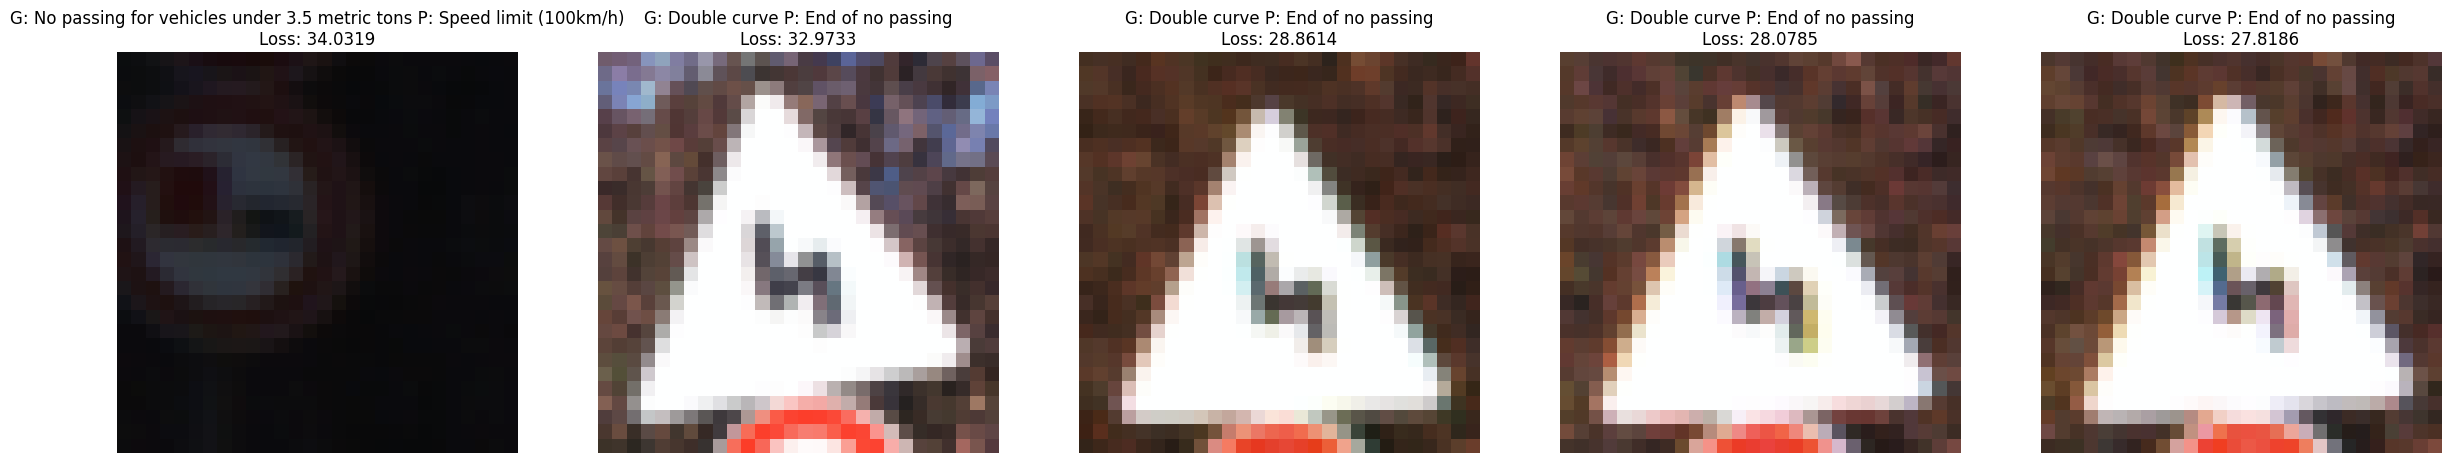

In [203]:
visualize_top5_incorrect(model_cnn, test_loader, categories)

<div class="alert alert-block alert-success">
    
## Task 3.6: Discussion Questions <a class="anchor" id="t3_6"></a>
    
## Questions
    
1. List the different ways you have tried to optimize your model and discuss why you chose those methods.

2. Show how you calculated the input size of the fully connected layer right after all the convolutional blocks. 

3. Please talk and discuss about the first additional analysis you have performed. What can you deduce from the analysis?

4. Please talk and discuss about the second additional analysis you have performed. What can you deduce from the analysis?
    

    
## Answers

1. - Use the Adam optimizer: Able to quickly find local optimal solutions in complex loss functions. Convergence speed is faster.
   - Add MaxPooling can reduce the size of feature maps and reduce computational complexity. 
   - Add BatchNorm2d to normalize data, which can improve convergence speed.

2. Step1: Input image is resized to 28×28 pixels with 3 channels (RGB)

   Step2: conv_blk1: Input has 3 channels, outputs 32 channels.<br>
          conv_blk2: Input has 32 channels, outputs 64 channels.<br>
          conv_blk3: Input has 64 channels, outputs 128 channels.
   
   Step3: conv_blk1: Input size is 28×28. After a Conv2d layer with padding 1 and kernel size 3, the output remains 28*28. The MaxPool2d layer reduces the size to 28/2 = 14, so the output size is 14*14.

   conv_blk2: Input size is 14*14. After a similar convolution and pooling operation, the size becomes 14/2 = 7, so the output size is 7*7. 

   conv_blk3: Input size is 7*7. After the convolution and pooling, the size becomes 7/2 = 3.5, which rounds down to 3*3

   Step4: Finally, the output size is 128*3*3 (128 channels). To make this output ready for use in a fully connected layer, it needs to be flattened into a vector. The flattened size is 128*3*3 = 1152


   

3. By generating saliency maps for correctly classified images, it can be seen that the model pays more attention to the salient features of traffic signs and ignores background or irrelevant information. This shows that the model can learn meaningful features and focus on key parts of traffic signs, helping to classify them more accurately.

4. By showing the examples that the model misclassified, and showing their actual and predicted labels, can find out which specific categories the model is prone to confusion. These errors are due to blurred images and the visual similarity of certain traffic signs.
